In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_DIR = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

OUTPUT_RASTERS = os.path.join(PROJECT_DIR, "outputs", "rasters")
OUTPUT_FIGURES = os.path.join(PROJECT_DIR, "outputs", "figures")

RAINFALL_PATH = os.path.join(
    OUTPUT_RASTERS,
    "rainfall.tif"
)

print(RAINFALL_PATH)
print(os.path.exists(RAINFALL_PATH))

/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/rainfall.tif
True


In [4]:
with rasterio.open(RAINFALL_PATH) as src:
    rainfall = src.read(1)
    profile = src.profile

print(profile)
print("Shape:", rainfall.shape)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 87, 'height': 121, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32643"]]'), 'transform': Affine(1000.0, 0.0, 678000.0,
       0.0, -1000.0, 1146000.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
Shape: (121, 87)


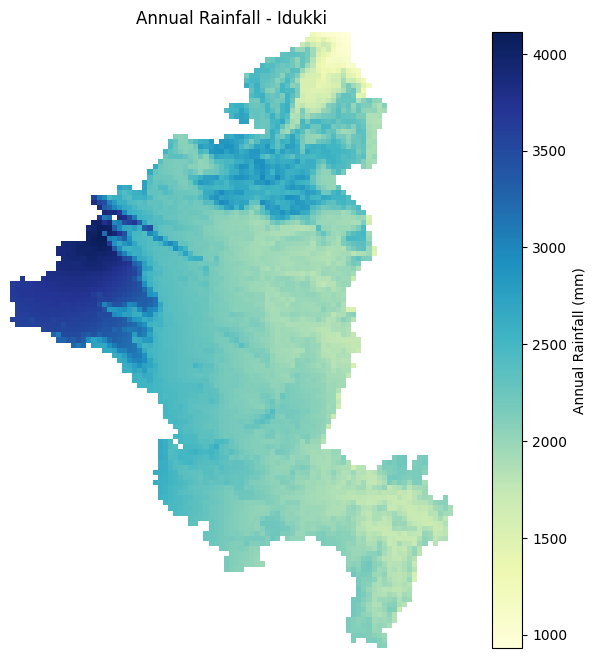

In [5]:
plt.figure(figsize=(10,8))

plt.imshow(rainfall, cmap="YlGnBu")
plt.colorbar(label="Annual Rainfall (mm)")

plt.title("Annual Rainfall - Idukki")
plt.axis("off")

plt.show()

In [6]:
rain_valid = rainfall[np.isfinite(rainfall)]

print(f"Minimum Rainfall : {rain_valid.min():.2f} mm")
print(f"Maximum Rainfall : {rain_valid.max():.2f} mm")
print(f"Mean Rainfall    : {rain_valid.mean():.2f} mm")
print(f"Std Dev          : {rain_valid.std():.2f} mm")

Minimum Rainfall : 931.00 mm
Maximum Rainfall : 4112.00 mm
Mean Rainfall    : 2309.85 mm
Std Dev          : 525.01 mm


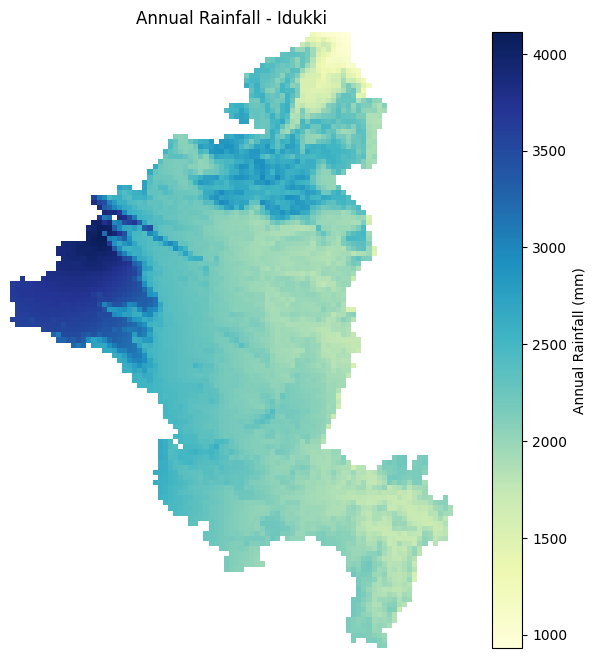

Saved: /content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/rainfall_map.png


In [7]:
figure_path = os.path.join(
    OUTPUT_FIGURES,
    "rainfall_map.png"
)

plt.figure(figsize=(10,8))

plt.imshow(rainfall, cmap="YlGnBu")
plt.colorbar(label="Annual Rainfall (mm)")

plt.title("Annual Rainfall - Idukki")
plt.axis("off")

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

print("Saved:", figure_path)